<a href="https://colab.research.google.com/github/true-cpu/ThucHanhDeepLearning/blob/main/Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/heart_disease_dataset.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display information about the DataFrame, including data types and non-null values
print("\nDataFrame Information:")
df.info()

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB


In [2]:
# Check for missing values
print("\nMissing values in each column:")
display(df.isnull().sum())


Missing values in each column:


,0
age,8
sex,8
cp,11
trestbps,8
chol,10
fbs,8
restecg,8
thalach,12
exang,8
oldpeak,8


In [3]:
# Drop rows with any missing values
df_cleaned = df.dropna()

# Verify that missing values have been handled
print("\nMissing values after dropping rows with NaNs:")
display(df_cleaned.isnull().sum())

print("\nFirst 5 rows of the cleaned dataset:")
display(df_cleaned.head())

print("\nShape of the original dataset:", df.shape)
print("Shape of the cleaned dataset:", df_cleaned.shape)


Missing values after dropping rows with NaNs:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



First 5 rows of the cleaned dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0



Shape of the original dataset: (303, 14)
Shape of the cleaned dataset: (284, 14)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Xác định biến mục tiêu (y) và các biến đặc trưng (X)
X = df_cleaned.drop('state', axis=1)
y = df_cleaned['state']

# Xác định các cột phân loại và số
# Dựa trên df.info() từ bước trước, các cột 'object' là phân loại, còn lại là số
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns

print("Các biến phân loại:", list(categorical_features))
print("Các biến số:", list(numerical_features))

# Tạo bộ tiền xử lý (preprocessor) cho các biến số và phân loại
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nKích thước tập huấn luyện X: {X_train.shape}")
print(f"Kích thước tập kiểm tra X: {X_test.shape}")
print(f"Kích thước tập huấn luyện y: {y_train.shape}")
print(f"Kích thước tập kiểm tra y: {y_test.shape}")

Các biến phân loại: ['sex', 'cp', 'fbs']
Các biến số: ['age', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Kích thước tập huấn luyện X: (227, 13)
Kích thước tập kiểm tra X: (57, 13)
Kích thước tập huấn luyện y: (227,)
Kích thước tập kiểm tra y: (57,)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Tạo pipeline bao gồm tiền xử lý và mô hình Logistic Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')) # multi_class='auto' for handling multiple classes
])

# Huấn luyện mô hình
print("Đang huấn luyện mô hình...")
model.fit(X_train, y_train)
print("Huấn luyện hoàn tất.")

# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nĐộ chính xác của mô hình: {accuracy:.4f}")
print("\nBáo cáo phân loại:\n", report)

Đang huấn luyện mô hình...
Huấn luyện hoàn tất.

Độ chính xác của mô hình: 0.5789

Báo cáo phân loại:
               precision    recall  f1-score   support

         0.0       0.67      0.97      0.79        31
         1.0       0.25      0.10      0.14        10
         2.0       0.33      0.14      0.20         7
         3.0       0.25      0.17      0.20         6
         4.0       0.00      0.00      0.00         3

    accuracy                           0.58        57
   macro avg       0.30      0.28      0.27        57
weighted avg       0.47      0.58      0.50        57



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Áp dụng quy trình cho tập dữ liệu Titanic

Chúng ta sẽ thực hiện các bước tương tự như với tập dữ liệu bệnh tim:
1.  Tải dữ liệu.
2.  Làm sạch và tiền xử lý dữ liệu.
3.  Huấn luyện mô hình và dự đoán tỉ lệ sống sót (survival).

In [6]:
import pandas as pd

# Load the Titanic dataset
df_titanic = pd.read_csv('/content/titanic_disaster.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the Titanic dataset:")
display(df_titanic.head())

# Display information about the DataFrame
print("\nDataFrame Information (Titanic):")
df_titanic.info()

First 5 rows of the Titanic dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



DataFrame Information (Titanic):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Check for missing values in Titanic dataset
print("\nMissing values in each column (Titanic):")
display(df_titanic.isnull().sum())


Missing values in each column (Titanic):


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Làm sạch dữ liệu Titanic

1.  **Xử lý các giá trị thiếu:**
    *   `Age`: Điền giá trị thiếu bằng `median` (giá trị trung vị).
    *   `Embarked`: Điền giá trị thiếu bằng `mode` (giá trị xuất hiện nhiều nhất).
    *   `Cabin`: Loại bỏ cột này do có quá nhiều giá trị thiếu.
2.  **Loại bỏ các đặc trưng không cần thiết:** `PassengerId`, `Name`, `Ticket` thường không hữu ích cho việc dự đoán sống sót.

In [8]:
# Make a copy to avoid modifying the original DataFrame directly
df_titanic_cleaned = df_titanic.copy()

# Impute 'Age' with the median
df_titanic_cleaned['Age'].fillna(df_titanic_cleaned['Age'].median(), inplace=True)

# Impute 'Embarked' with the mode
df_titanic_cleaned['Embarked'].fillna(df_titanic_cleaned['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' due to too many missing values
df_titanic_cleaned.drop('Cabin', axis=1, inplace=True)

# Drop irrelevant columns
df_titanic_cleaned.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# Verify that missing values have been handled
print("\nMissing values after cleaning (Titanic):")
display(df_titanic_cleaned.isnull().sum())

print("\nFirst 5 rows of the cleaned Titanic dataset:")
display(df_titanic_cleaned.head())

print("\nDataFrame Information after cleaning (Titanic):")
df_titanic_cleaned.info()


Missing values after cleaning (Titanic):


/tmp/ipykernel_6763/3968458870.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic_cleaned['Age'].fillna(df_titanic_cleaned['Age'].median(), inplace=True)
/tmp/ipykernel_6763/3968458870.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0



First 5 rows of the cleaned Titanic dataset:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S



DataFrame Information after cleaning (Titanic):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


### Chuẩn bị dữ liệu cho huấn luyện mô hình dự đoán sống sót trên Titanic

Giống như ví dụ bệnh tim, chúng ta sẽ:
1.  **Xác định biến mục tiêu (`Survived`)** và các biến đặc trưng.
2.  **Xác định các cột phân loại và số** cho việc tiền xử lý.
3.  **Chia dữ liệu** thành tập huấn luyện và tập kiểm tra.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Xác định biến mục tiêu (y) và các biến đặc trưng (X)
X_titanic = df_titanic_cleaned.drop('Survived', axis=1)
y_titanic = df_titanic_cleaned['Survived']

# Xác định các cột phân loại và số
categorical_features_titanic = X_titanic.select_dtypes(include=['object']).columns
numerical_features_titanic = X_titanic.select_dtypes(include=['float64', 'int64']).columns

print("Các biến phân loại (Titanic):", list(categorical_features_titanic))
print("Các biến số (Titanic):", list(numerical_features_titanic))

# Tạo bộ tiền xử lý (preprocessor) cho các biến số và phân loại
preprocessor_titanic = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_titanic),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_titanic)
    ])

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic)

print(f"\nKích thước tập huấn luyện X (Titanic): {X_train_titanic.shape}")
print(f"Kích thước tập kiểm tra X (Titanic): {X_test_titanic.shape}")
print(f"Kích thước tập huấn luyện y (Titanic): {y_train_titanic.shape}")
print(f"Kích thước tập kiểm tra y (Titanic): {y_test_titanic.shape}")

Các biến phân loại (Titanic): ['Sex', 'Embarked']
Các biến số (Titanic): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Kích thước tập huấn luyện X (Titanic): (712, 7)
Kích thước tập kiểm tra X (Titanic): (179, 7)
Kích thước tập huấn luyện y (Titanic): (712,)
Kích thước tập kiểm tra y (Titanic): (179,)


### Huấn luyện và đánh giá mô hình dự đoán sống sót Titanic

Chúng ta sẽ sử dụng mô hình Hồi quy Logistic để dự đoán khả năng sống sót (`Survived`) của hành khách. Sau đó, chúng ta sẽ đánh giá hiệu suất của mô hình trên tập kiểm tra.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Tạo pipeline bao gồm tiền xử lý và mô hình Logistic Regression
model_titanic = Pipeline(steps=[
    ('preprocessor', preprocessor_titanic),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Huấn luyện mô hình
print("Đang huấn luyện mô hình dự đoán sống sót Titanic...")
model_titanic.fit(X_train_titanic, y_train_titanic)
print("Huấn luyện hoàn tất.")

# Dự đoán trên tập kiểm tra
y_pred_titanic = model_titanic.predict(X_test_titanic)

# Đánh giá mô hình
accuracy_titanic = accuracy_score(y_test_titanic, y_pred_titanic)
report_titanic = classification_report(y_test_titanic, y_pred_titanic)

print(f"\nĐộ chính xác của mô hình Titanic: {accuracy_titanic:.4f}")
print("\nBáo cáo phân loại (Titanic):\n", report_titanic)

Đang huấn luyện mô hình dự đoán sống sót Titanic...
Huấn luyện hoàn tất.

Độ chính xác của mô hình Titanic: 0.8045

Báo cáo phân loại (Titanic):
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Ma trận nhầm lẫn (Confusion Matrix) cho mô hình Titanic

Để hiểu rõ hơn về hiệu suất của mô hình, đặc biệt là cách nó phân loại sống sót (1) và không sống sót (0), chúng ta sẽ trực quan hóa ma trận nhầm lẫn.

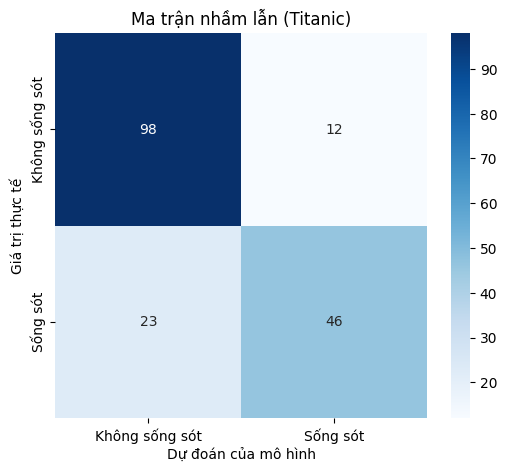

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính toán ma trận nhầm lẫn
cm_titanic = confusion_matrix(y_test_titanic, y_pred_titanic)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_titanic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không sống sót', 'Sống sót'],
            yticklabels=['Không sống sót', 'Sống sót'])
plt.xlabel('Dự đoán của mô hình')
plt.ylabel('Giá trị thực tế')
plt.title('Ma trận nhầm lẫn (Titanic)')
plt.show()